# 03 — Model Training, K-Fold Evaluation, and Best Model Selection

**Competition metric:** Model Performance / Evaluation Metrics (20%).

Notebook ini memakai output dari Notebook 02:

- `outputs/02_modeling_dataset.csv`

Target model adalah `readiness_label`, yaitu pseudo label hasil weak supervision berbasis rule + clustering. Karena dataset tidak menyediakan ground truth eksternal, evaluasi dilakukan terhadap **pseudo label** dan konsistensi performa model.

Perbaikan utama versi ini:

1. memakai **Stratified K-Fold Cross Validation**,
2. membandingkan banyak model tabular,
3. menambahkan model opsional: **XGBoost, LightGBM, CatBoost** jika package tersedia,
4. memilih model terbaik berdasarkan **Macro F1** dan **Balanced Accuracy**,
5. menyimpan hasil evaluasi, confusion matrix, prediction output, feature importance, dan model terbaik.

In [14]:
from pathlib import Path
import json, warnings, importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, HistGradientBoostingClassifier
)
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
PLOT_DIR = OUTPUT_DIR / 'plots'
MODEL_DIR = OUTPUT_DIR / 'models'
PLOT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (10, 5.8),
    'figure.dpi': 120,
    'savefig.dpi': 180,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlepad': 12,
    'axes.labelsize': 10,
    'axes.titlesize': 14,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'grid.alpha': 0.25,
    'legend.frameon': False,
})

COLORS = {'ink':'#1f2937','muted':'#6b7280','good':'#2a9d8f','warn':'#e9c46a','bad':'#e76f51','blue':'#457b9d'}

def savefig(name):
    path = PLOT_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    print(f'Saved: {path}')
    plt.show()

## 1. Load modeling dataset

Jika file tidak ditemukan, jalankan Notebook 01 lalu Notebook 02 terlebih dahulu.

In [15]:
modeling_path = OUTPUT_DIR / '02_modeling_dataset.csv'
if not modeling_path.exists():
    raise FileNotFoundError('outputs/02_modeling_dataset.csv tidak ditemukan. Jalankan Notebook 01 dan 02 terlebih dahulu.')

df = pd.read_csv(modeling_path)
TARGET = 'readiness_label'
if TARGET not in df.columns:
    raise ValueError(f'Kolom target {TARGET} tidak ditemukan di dataset modeling.')

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=[TARGET]).copy()
# keep label order readable
label_order = ['Not Recommended', 'Conditional', 'Recommended']
existing_order = [x for x in label_order if x in df[TARGET].unique()]
print('Dataset shape:', df.shape)
print('Target distribution:')
display(df[TARGET].value_counts().reindex(existing_order).dropna().rename_axis(TARGET).reset_index(name='count'))
display(df.head())

Dataset shape: (787, 76)
Target distribution:


,readiness_label,count
0,Not Recommended,128
1,Conditional,314
2,Recommended,345


,actor,region,dmu,total_cost,output_value,margin,rc_ratio,margin_ratio,quantity_proxy,cost_per_quantity,output_per_quantity,asset_proxy,asset_utilization,dea_score,dea_score_filled,rc_viability_score,margin_score,asset_utilization_score,cost_burden_score,crisis_resilience_score,crisis_sensitivity_score,cluster,cluster_support_score,readiness_score,readiness_label,vote_ready,vote_high_risk,label_reason,land_area,land_lease_value_idr,labor_cost_idr,seed_purchase_value_idr,fertilizer_purchase_value_idr,pesticide_purchase_value_idr,equipment_rent_value_idr,production_value_idr,number_of_machines,value_of_milled_grains_idr,amount_of_milled_rice,supporting_equipment_cost_idr,value_of_milled_rice_idr,total_revenue_of_milling_machine_idr,total_rice_purchase_kg,total_rice_purchase_value_idr,building_rent_cost_idr,value_of_rice_sold_idr,total_precipitation,precipitation_quality,value_of_rice_purchase_idr,cost_to_output_ratio,labor_cost_share,building_rent_share,land_lease_share,supporting_equipment_share,equipment_rent_share,seed_cost_share,fertilizer_cost_share,pesticide_cost_share,rice_purchase_share,milled_grain_purchase_share,log_total_cost,log_output_value,log_quantity_proxy,log_asset_proxy,log_abs_margin,is_margin_negative,is_rc_below_one,cost_burden_raw,survive_cost_up_10,survive_output_down_10,survive_cost_up_20,survive_output_down_20,survive_cost_up_30,survive_output_down_30,survive_combined_10,survive_combined_20
0,Farmer,Garut,1,"11,418,000.0000","16,200,000.0000","4,782,000.0000",1.4188,0.4188,"2,800.0000","4,077.8571","5,785.7143","2,800.0000","5,785.7143",0.3644,0.3644,1.0000,0.2200,0.1462,0.2175,0.7500,0.2500,1,0.0000,0.4694,Conditional,2,2,low DEA efficiency; weak margin health; weak a...,"2,800.0000","4,900,000.0000","1,400,000.0000","644,000.0000","3,640,000.0000","364,000.0000","470,000.0000","16,200,000.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.7048,0.1226,NaN,0.4291,NaN,0.0412,0.0564,0.3188,0.0319,NaN,NaN,16.2507,16.6005,7.9377,7.9377,15.3804,0,0,0.7048,1,1,1,1,1,0,1,0
1,Farmer,Garut,2,"8,264,000.0000","8,100,000.0000","-164,000.0000",0.9802,-0.0198,"1,400.0000","5,902.8571","5,785.7143","1,400.0000","5,785.7143",0.3650,0.3650,0.7841,0.0825,0.1462,0.0800,0.0000,1.0000,1,0.0000,0.2933,Not Recommended,0,4,low DEA efficiency; weak margin health; high c...,"1,400.0000","4,900,000.0000","500,000.0000","322,000.0000","1,820,000.0000","182,000.0000","540,000.0000","8,100,000.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0202,0.0605,NaN,0.5929,NaN,0.0653,0.0390,0.2202,0.0220,NaN,NaN,15.9274,15.9074,7.2449,7.2449,12.0076,1,1,1.0202,0,0,0,0,0,0,0,0
2,Farmer,Garut,3,"6,450,000.0000","14,850,000.0000","8,400,000.0000",2.3023,1.3023,"2,000.0000","3,225.0000","7,425.0000","2,000.0000","7,425.0000",0.4356,0.4356,1.0000,0.5700,0.3412,0.5675,1.0000,0.0000,0,1.0000,0.7003,Recommended,2,1,weak asset utilization,"2,000.0000","2,000,000.0000","700,000.0000","200,000.0000","2,600,000.0000","260,000.0000","690,000.0000","14,850,000.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4343,0.1085,NaN,0.3101,NaN,0.1070,0.0310,0.4031,0.0403,NaN,NaN,15.6796,16.5135,7.6014,7.6014,15.9437,0,0,0.4343,1,1,1,1,1,1,1,1
3,Farmer,Garut,4,"4,570,000.0000","13,050,000.0000","8,480,000.0000",2.8556,1.8556,"1,000.0000","4,570.0000","13,050.0000","1,000.0000","13,050.0000",0.7445,0.7445,1.0000,0.7475,0.6825,0.7450,1.0000,0.0000,0,1.0000,0.8537,Recommended,3,0,balanced domain indicators,"1,000.0000","1,800,000.0000","800,000.0000","230,000.0000","1,300,000.0000","100,000.0000","340,000.0000","13,050,000.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3502,0.1751,NaN,0.3939,NaN,0.0744,0.0503,0.2845,0.0219,NaN,NaN,15.3350,16.3843,6.9088,6.9088,15.9532,0,0,0.3502,1,1,1,1,1,1,1,1
4,Farmer,Garut,5,"3,778,000.0000","10,200,000.0000","6,422,000.0000",2.6998,1.6998,800.0000,"4,722.5000","12,750.0000",800.0000,"12,750.0000",0.6499,0.6499,1.0000,0.7025,0.5825,0.7000,1.0000,0.0000,0,1.0000,0.8086,Recommended,3,0,bala

## 2. Feature set

Feature yang dipakai sengaja tidak memasukkan `readiness_score` karena itu skor final yang membentuk pseudo label. Model tetap boleh memakai indikator hasil feature engineering seperti R/C, margin, DEA score, dan crisis score karena indikator tersebut bisa dihitung ulang untuk data baru.

In [16]:
leakage_cols = {
    TARGET,
    'readiness_score',
    'readiness_label',
    'cluster_support_score',  # cluster meaning support, not raw observation
}

candidate_features = [
    'actor', 'region',
    'total_cost', 'output_value', 'margin', 'rc_ratio', 'margin_ratio',
    'quantity_proxy', 'cost_per_quantity', 'output_per_quantity',
    'asset_proxy', 'asset_utilization',
    'labor_cost_share', 'building_rent_share', 'land_lease_share',
    'supporting_equipment_share', 'equipment_rent_share',
    'dea_score', 'dea_score_filled',
    'rc_viability_score', 'asset_utilization_score', 'crisis_resilience_score',
    'cluster',
]

feature_cols = [c for c in candidate_features if c in df.columns and c not in leakage_cols]
X = df[feature_cols].copy()
y = df[TARGET].astype(str).copy()

cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_features = [c for c in X.columns if c not in cat_features]

print('Total features:', len(feature_cols))
print('Categorical features:', cat_features)
print('Numeric features:', num_features)

display(X.head())

Total features: 23
Categorical features: ['actor', 'region']
Numeric features: ['total_cost', 'output_value', 'margin', 'rc_ratio', 'margin_ratio', 'quantity_proxy', 'cost_per_quantity', 'output_per_quantity', 'asset_proxy', 'asset_utilization', 'labor_cost_share', 'building_rent_share', 'land_lease_share', 'supporting_equipment_share', 'equipment_rent_share', 'dea_score', 'dea_score_filled', 'rc_viability_score', 'asset_utilization_score', 'crisis_resilience_score', 'cluster']


,actor,region,total_cost,output_value,margin,rc_ratio,margin_ratio,quantity_proxy,cost_per_quantity,output_per_quantity,asset_proxy,asset_utilization,labor_cost_share,building_rent_share,land_lease_share,supporting_equipment_share,equipment_rent_share,dea_score,dea_score_filled,rc_viability_score,asset_utilization_score,crisis_resilience_score,cluster
0,Farmer,Garut,"11,418,000.0000","16,200,000.0000","4,782,000.0000",1.4188,0.4188,"2,800.0000","4,077.8571","5,785.7143","2,800.0000","5,785.7143",0.1226,NaN,0.4291,NaN,0.0412,0.3644,0.3644,1.0000,0.1462,0.7500,1
1,Farmer,Garut,"8,264,000.0000","8,100,000.0000","-164,000.0000",0.9802,-0.0198,"1,400.0000","5,902.8571","5,785.7143","1,400.0000","5,785.7143",0.0605,NaN,0.5929,NaN,0.0653,0.3650,0.3650,0.7841,0.1462,0.0000,1
2,Farmer,Garut,"6,450,000.0000","14,850,000.0000","8,400,000.0000",2.3023,1.3023,"2,000.0000","3,225.0000","7,425.0000","2,000.0000","7,425.0000",0.1085,NaN,0.3101,NaN,0.1070,0.4356,0.4356,1.0000,0.3412,1.0000,0
3,Farmer,Garut,"4,570,000.0000","13,050,000.0000","8,480,000.0000",2.8556,1.8556,"1,000.0000","4,570.0000","13,050.0000","1,000.0000","13,050.0000",0.1751,NaN,0.3939,NaN,0.0744,0.7445,0.7445,1.0000,0.6825,1.0000,0
4,Farmer,Garut,"3,778,000.0000","10,200,000.0000","6,422,000.0000",2.6998,1.6998,800.0000,"4,722.5000","12,750.0000",800.0000,"12,750.0000",0.1535,NaN,0.4023,NaN,0.0926,0.6499,0.6499,1.0000,0.5825,1.0000,0


## 3. Preprocessing pipeline

Semua model dibandingkan dengan preprocessing yang sama:

- numeric: median imputation + standard scaler,
- categorical: most frequent imputation + one-hot encoding.

In [17]:
def make_onehot():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', make_onehot())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

class EncodedYClassifier(BaseEstimator, ClassifierMixin):
    """Wrapper for estimators that require numeric y labels, such as many XGBoost versions."""
    def __init__(self, estimator):
        self.estimator = estimator
    def fit(self, X, y):
        self.label_encoder_ = LabelEncoder()
        y_enc = self.label_encoder_.fit_transform(y)
        self.estimator_ = clone(self.estimator)
        self.estimator_.fit(X, y_enc)
        self.classes_ = self.label_encoder_.classes_
        return self
    def predict(self, X):
        pred = self.estimator_.predict(X)
        pred = np.asarray(pred).astype(int)
        return self.label_encoder_.inverse_transform(pred)
    def predict_proba(self, X):
        if hasattr(self.estimator_, 'predict_proba'):
            return self.estimator_.predict_proba(X)
        raise AttributeError('Underlying estimator has no predict_proba')

print('Preprocessor ready.')

Preprocessor ready.


## 4. Model zoo

Model opsional akan otomatis ditambahkan jika library tersedia. Kalau `xgboost`, `lightgbm`, atau `catboost` belum ter-install, notebook tetap jalan dan model tersebut akan dilewati.

In [18]:
def has_package(name):
    return importlib.util.find_spec(name) is not None

models = {
    'Dummy Most Frequent': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42),
    'Ridge Classifier': RidgeClassifier(class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=None, min_samples_leaf=4, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=60, min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesClassifier(n_estimators=60, min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=40, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=35, learning_rate=0.05, random_state=42),
    'Linear SVM': LinearSVC(class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5, weights='distance'),
}

optional_status = []

if has_package('xgboost'):
    try:
        from xgboost import XGBClassifier
        xgb = XGBClassifier(
            n_estimators=35,
            max_depth=3,
            learning_rate=0.04,
            subsample=0.85,
            colsample_bytree=0.85,
            objective='multi:softprob',
            eval_metric='mlogloss',
            random_state=42,
            n_jobs=1,
            tree_method='hist',
            verbosity=0,
        )
        models['XGBoost'] = EncodedYClassifier(xgb)
        optional_status.append(('XGBoost', 'available'))
    except Exception as e:
        optional_status.append(('XGBoost', f'skipped: {e}'))
else:
    optional_status.append(('XGBoost', 'not installed'))

if has_package('lightgbm'):
    try:
        from lightgbm import LGBMClassifier
        models['LightGBM'] = LGBMClassifier(
            n_estimators=50,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.85,
            colsample_bytree=0.85,
            random_state=42,
            n_jobs=1,
            verbose=-1,
        )
        optional_status.append(('LightGBM', 'available'))
    except Exception as e:
        optional_status.append(('LightGBM', f'skipped: {e}'))
else:
    optional_status.append(('LightGBM', 'not installed'))

if has_package('catboost'):
    try:
        from catboost import CatBoostClassifier
        models['CatBoost'] = CatBoostClassifier(
            iterations=50,
            depth=4,
            learning_rate=0.03,
            loss_function='MultiClass',
            random_seed=42,
            verbose=False,
            allow_writing_files=False,
            thread_count=1,
        )
        optional_status.append(('CatBoost', 'available'))
    except Exception as e:
        optional_status.append(('CatBoost', f'skipped: {e}'))
else:
    optional_status.append(('CatBoost', 'not installed'))

pipes = {name: Pipeline(steps=[('preprocess', preprocessor), ('model', clf)]) for name, clf in models.items()}
print('Models included:', len(pipes))
display(pd.DataFrame(optional_status, columns=['optional_model','status']))

Models included: 13


,optional_model,status
0,XGBoost,available
1,LightGBM,available
2,CatBoost,available


## 5. Stratified K-Fold cross-validation

Metric utama:

- **Macro F1**: penting karena semua kelas dianggap sama penting,
- **Balanced Accuracy**: penting jika distribusi pseudo label tidak seimbang,
- Accuracy dan Weighted F1 tetap dilaporkan sebagai tambahan.

In [19]:
min_class = y.value_counts().min()
n_splits = int(min(3, min_class))
if n_splits < 2:
    raise ValueError('Tidak cukup data per kelas untuk Stratified K-Fold. Periksa distribusi target.')

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted',
}

cv_rows = []
failed_models = []
for name, pipe in pipes.items():
    print(f'Running CV: {name}')
    try:
        scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=1, error_score='raise', return_train_score=False)
        row = {'model': name}
        for metric in scoring:
            vals = scores[f'test_{metric}']
            row[f'{metric}_mean'] = float(np.mean(vals))
            row[f'{metric}_std'] = float(np.std(vals))
        row['fit_time_mean'] = float(np.mean(scores['fit_time']))
        cv_rows.append(row)
    except Exception as e:
        failed_models.append({'model': name, 'error': str(e)[:300]})

cv_results = pd.DataFrame(cv_rows)
cv_results['selection_score'] = 0.60 * cv_results['f1_macro_mean'] + 0.40 * cv_results['balanced_accuracy_mean']
cv_results = cv_results.sort_values(['selection_score','f1_macro_mean','balanced_accuracy_mean'], ascending=False).reset_index(drop=True)

print('K-Fold:', n_splits)
display(cv_results)
if failed_models:
    print('\nFailed / skipped during CV:')
    display(pd.DataFrame(failed_models))

cv_results.to_csv(OUTPUT_DIR / '03_cv_model_comparison.csv', index=False)
if failed_models:
    pd.DataFrame(failed_models).to_csv(OUTPUT_DIR / '03_failed_models.csv', index=False)

Running CV: Dummy Most Frequent
Running CV: Logistic Regression
Running CV: Ridge Classifier
Running CV: Decision Tree
Running CV: Random Forest
Running CV: Extra Trees
Running CV: Gradient Boosting
Running CV: AdaBoost
Running CV: Linear SVM
Running CV: KNN
Running CV: XGBoost
Running CV: LightGBM
Running CV: CatBoost
K-Fold: 3


,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,fit_time_mean,selection_score
0,Extra Trees,0.9479,0.0079,0.9430,0.0160,0.9446,0.0144,0.9475,0.0081,0.1349,0.9440
1,Logistic Regression,0.9402,0.0243,0.9417,0.0238,0.9342,0.0279,0.9401,0.0244,0.0235,0.9372
2,Random Forest,0.9352,0.0083,0.9254,0.0107,0.9311,0.0099,0.9350,0.0083,0.1341,0.9288
3,Linear SVM,0.9314,0.0219,0.9266,0.0276,0.9234,0.0261,0.9313,0.0220,0.0153,0.9247
4,Gradient Boosting,0.9250,0.0079,0.9187,0.0070,0.9241,0.0103,0.9249,0.0079,0.3690,0.9220
5,LightGBM,0.9301,0.0096,0.9119,0.0111,0.9230,0.0111,0.9298,0.0097,0.0769,0.9185
6,Decision Tree,0.8958,0.0049,0.8984,0.0097,0.8937,0.0107,0.8958,0.0052,0.0188,0.8956
7,KNN,0.8894,0.0056,0.8665,0.0030,0.8779,0.0063,0.8888,0.0053,0.0111,0.8733
8,CatBoost,0.8843,0.0142,0.8465,0.0178,0.8666,0.0173,0.8824,0.0148,0.3172,0.8586
9,XGBoost,0.8805,0.0235,0.8435,0.0258,0.8622,0.0247,0.8789,0.0241,0.0743,0.8547


## 6. Visual comparison: model terbaik berdasarkan CV

Grafik ini menampilkan model yang paling kuat berdasarkan Macro F1. Error bar menunjukkan standar deviasi antar fold.

Saved: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\plots\03_cv_macro_f1_model_comparison.png


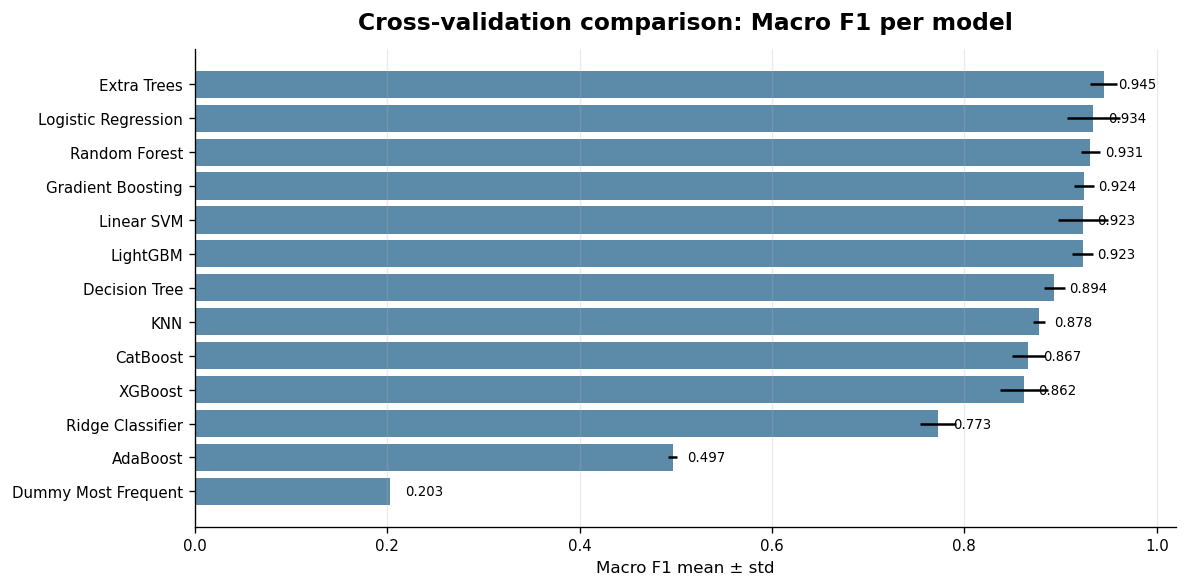

In [20]:
plot_cv = cv_results.sort_values('f1_macro_mean', ascending=True)
fig, ax = plt.subplots(figsize=(10, max(5, 0.38 * len(plot_cv))))
ax.barh(plot_cv['model'], plot_cv['f1_macro_mean'], xerr=plot_cv['f1_macro_std'], color=COLORS['blue'], alpha=0.88)
ax.set_xlim(0, 1.02)
ax.set_xlabel('Macro F1 mean ± std')
ax.set_title('Cross-validation comparison: Macro F1 per model')
ax.grid(axis='x')
for i, (_, r) in enumerate(plot_cv.iterrows()):
    ax.text(min(r['f1_macro_mean'] + 0.015, 0.98), i, f"{r['f1_macro_mean']:.3f}", va='center', fontsize=8)
savefig('03_cv_macro_f1_model_comparison.png')

## 7. Holdout evaluation untuk model terbaik

CV dipakai untuk memilih model. Holdout split dipakai sebagai sanity check tambahan agar ada confusion matrix dan classification report yang mudah dibaca.

In [21]:
# Split holdout after CV model selection
stratify_arg = y if y.value_counts().min() >= 2 else None
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=stratify_arg
)

best_model_name = cv_results.iloc[0]['model']
best_pipe = pipes[best_model_name]
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

holdout_metrics = {
    'best_model': best_model_name,
    'accuracy': float(accuracy_score(y_test, y_pred)),
    'balanced_accuracy': float(balanced_accuracy_score(y_test, y_pred)),
    'f1_macro': float(f1_score(y_test, y_pred, average='macro')),
    'f1_weighted': float(f1_score(y_test, y_pred, average='weighted')),
}
print('Best model:', best_model_name)
display(pd.DataFrame([holdout_metrics]))

report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T
print('\nClassification report:')
display(report_df)

pd.DataFrame([holdout_metrics]).to_csv(OUTPUT_DIR / '03_best_model_holdout_metrics.csv', index=False)
report_df.to_csv(OUTPUT_DIR / '03_best_model_classification_report.csv')
with open(OUTPUT_DIR / '03_best_model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(holdout_metrics, f, indent=2)

Best model: Extra Trees


,best_model,accuracy,balanced_accuracy,f1_macro,f1_weighted
0,Extra Trees,0.9645,0.9588,0.9617,0.9645



Classification report:


,precision,recall,f1-score,support
Conditional,0.9500,0.9620,0.9560,79.0000
Not Recommended,0.9677,0.9375,0.9524,32.0000
Recommended,0.9767,0.9767,0.9767,86.0000
accuracy,0.9645,0.9645,0.9645,0.9645
macro avg,0.9648,0.9588,0.9617,197.0000
weighted avg,0.9646,0.9645,0.9645,197.0000


## 8. Confusion matrix

Confusion matrix membantu melihat kelas pseudo label mana yang paling sering tertukar.

Saved: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\plots\03_best_model_confusion_matrix.png


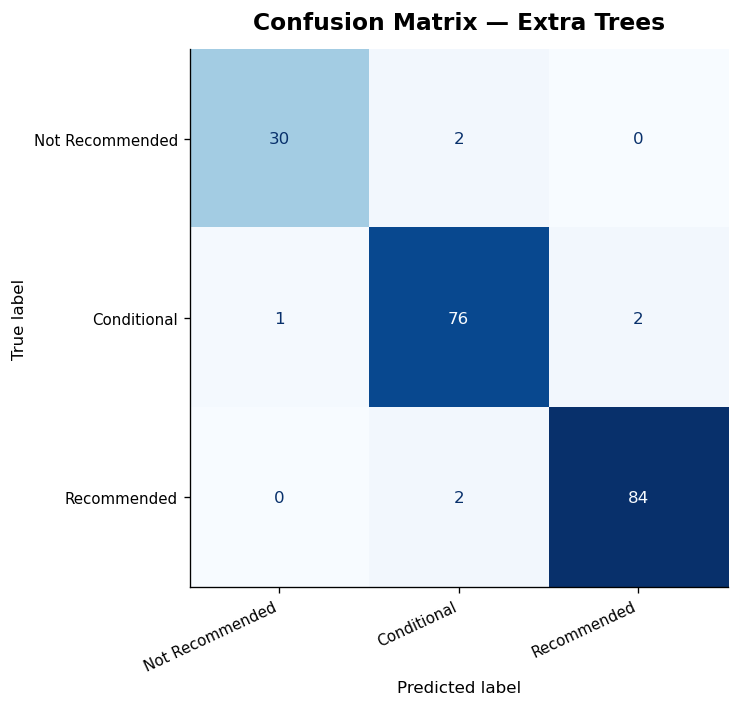

In [22]:
labels = [x for x in label_order if x in sorted(y.unique(), key=lambda z: label_order.index(z) if z in label_order else 99)]
cm = confusion_matrix(y_test, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(7.5, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title(f'Confusion Matrix — {best_model_name}')
plt.xticks(rotation=25, ha='right')
savefig('03_best_model_confusion_matrix.png')

## 9. Permutation feature importance

Permutation importance dipakai karena dapat bekerja untuk hampir semua jenis model, termasuk ensemble, SVM, MLP, XGBoost, LightGBM, dan CatBoost. Nilai importance menunjukkan seberapa besar performa turun saat fitur tersebut diacak.

,feature,importance_mean,importance_std
21,crisis_resilience_score,0.0961,0.0087
22,cluster,0.0833,0.0009
20,asset_utilization_score,0.0683,0.0183
17,dea_score,0.0206,0.0061
19,rc_viability_score,0.0201,0.0040
18,dea_score_filled,0.0157,0.0001
0,actor,0.0123,0.0017
6,margin_ratio,0.0102,0.0019
14,land_lease_share,0.0056,0.0020
2,total_cost,0.0040,0.0036


Saved: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\plots\03_best_model_permutation_importance.png


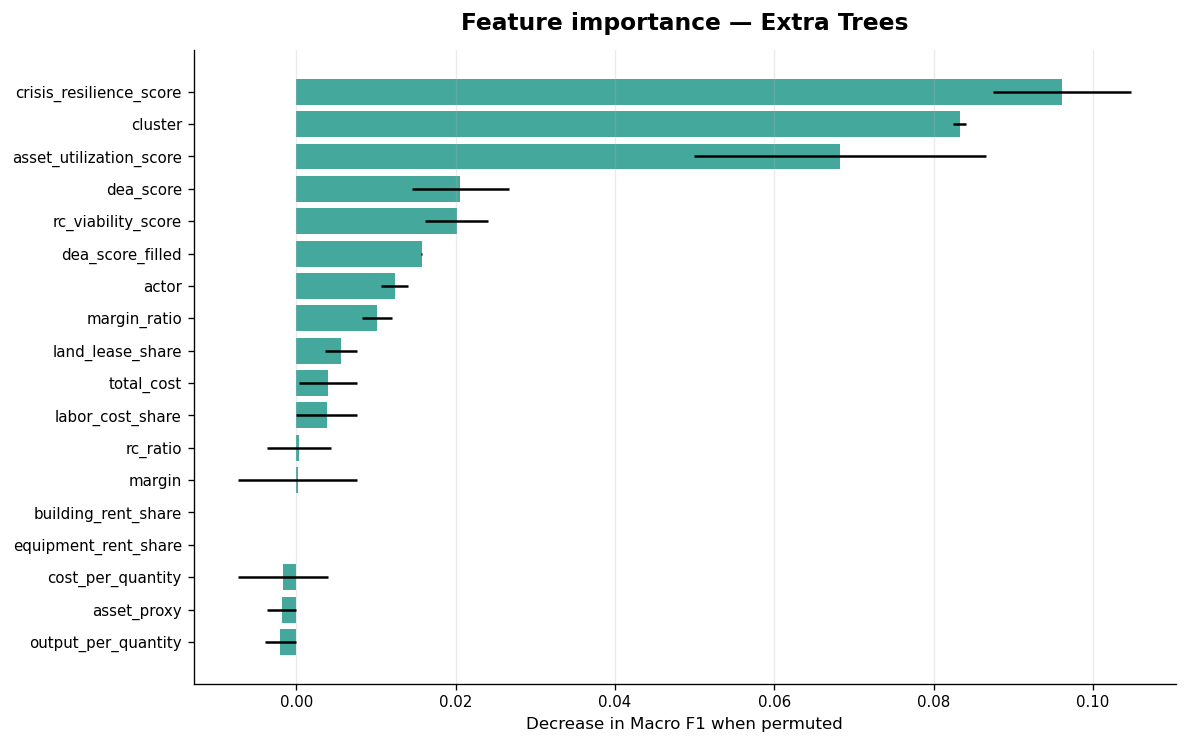

In [23]:
try:
    perm = permutation_importance(
        best_pipe, X_test, y_test,
        n_repeats=2,
        random_state=42,
        scoring='f1_macro',
        n_jobs=None
    )
    imp = pd.DataFrame({
        'feature': X.columns,
        'importance_mean': perm.importances_mean,
        'importance_std': perm.importances_std,
    }).sort_values('importance_mean', ascending=False)
    display(imp.head(20))
    imp.to_csv(OUTPUT_DIR / '03_permutation_feature_importance.csv', index=False)

    top_imp = imp.head(18).sort_values('importance_mean')
    fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(top_imp))))
    ax.barh(top_imp['feature'], top_imp['importance_mean'], xerr=top_imp['importance_std'], color=COLORS['good'], alpha=0.88)
    ax.set_xlabel('Decrease in Macro F1 when permuted')
    ax.set_title(f'Feature importance — {best_model_name}')
    ax.grid(axis='x')
    savefig('03_best_model_permutation_importance.png')
except Exception as e:
    print('Permutation importance skipped:', e)

## 10. Error analysis and prediction examples

Cell ini menyimpan prediksi holdout sehingga bisa dipakai untuk interpretasi di laporan/proposal.

In [24]:
pred_examples = X_test.copy()
pred_examples['true_pseudo_label'] = y_test.values
pred_examples['predicted_label'] = y_pred
pred_examples['is_correct'] = pred_examples['true_pseudo_label'] == pred_examples['predicted_label']

# Add probability/confidence if available
try:
    proba = best_pipe.predict_proba(X_test)
    pred_examples['prediction_confidence'] = proba.max(axis=1)
except Exception:
    pred_examples['prediction_confidence'] = np.nan

pred_examples.to_csv(OUTPUT_DIR / '03_holdout_predictions.csv', index=False)

print('Correct vs incorrect:')
display(pred_examples['is_correct'].value_counts().rename_axis('is_correct').reset_index(name='count'))

print('\nIncorrect examples, if any:')
display(pred_examples.loc[~pred_examples['is_correct']].head(10))

print('\nHigh confidence prediction examples:')
display(pred_examples.sort_values('prediction_confidence', ascending=False).head(10))

Correct vs incorrect:


,is_correct,count
0,True,190
1,False,7



Incorrect examples, if any:


,actor,region,total_cost,output_value,margin,rc_ratio,margin_ratio,quantity_proxy,cost_per_quantity,output_per_quantity,asset_proxy,asset_utilization,labor_cost_share,building_rent_share,land_lease_share,supporting_equipment_share,equipment_rent_share,dea_score,dea_score_filled,rc_viability_score,asset_utilization_score,crisis_resilience_score,cluster,true_pseudo_label,predicted_label,is_correct,prediction_confidence
654,Wholesaler,Karawang,"396,700,000.0000","380,000,000.0000","-16,700,000.0000",0.9579,-0.0421,NaN,NaN,NaN,NaN,0.9579,0.0202,0.0555,NaN,0.0169,NaN,0.1424,0.1424,0.7663,0.2763,0.0000,0,Not Recommended,Conditional,False,0.7780
178,Farmer,Karawang,"159,500,000.0000","208,000,000.0000","48,500,000.0000",1.3041,0.3041,"30,000.0000","5,316.6667","6,933.3333","30,000.0000","6,933.3333",0.0502,NaN,0.6207,NaN,0.0113,0.7465,0.7465,1.0000,0.2762,0.7500,0,Conditional,Recommended,False,0.5389
748,Retail,Subang,"2,100,000.0000","2,000,000.0000","-100,000.0000",0.9524,-0.0476,NaN,NaN,NaN,NaN,0.9524,0.0952,0.0952,NaN,0.0476,NaN,1.0000,1.0000,0.7619,0.9608,0.0000,1,Conditional,Recommended,False,0.6673
474,Rice Miller,Subang,"114,880,151.9468","102,763,298.6289","-12,116,853.3179",0.8945,-0.1055,"10,000.0000","11,488.0152","10,276.3299",4.0000,"25,690,824.6572",0.1252,NaN,NaN,0.0044,NaN,0.6610,0.6610,0.7156,0.2286,0.0000,1,Not Recommended,Conditional,False,0.5999
64,Farmer,Garut,"3,502,000.0000","8,100,000.0000","4,598,000.0000",2.3130,1.3130,"1,200.0000","2,918.3333","6,750.0000","1,200.0000","6,750.0000",0.1428,NaN,0.2056,NaN,0.0828,0.8068,0.8068,1.0000,0.2600,1.0000,1,Recommended,Conditional,False,0.5903
26,Farmer,Garut,"20,220,000.0000","49,500,000.0000","29,280,000.0000",2.4481,1.4481,"7,000.0000","2,888.5714","7,071.4286","7,000.0000","7,071.4286",0.0989,NaN,0.2423,NaN,0.0841,0.4543,0.4543,1.0000,0.3063,1.0000,0,Recommended,Conditional,False,0.5158
761,Retail,Tasikmalaya,"6,012,500.0000","3,000,000.0000","-3,012,500.0000",0.4990,-0.5010,NaN,NaN,NaN,NaN,0.4990,0.4990,0.0333,NaN,0.0333,NaN,0.7573,0.7573,0.3992,0.4167,0.0000,1,Conditional,Not Recommended,False,0.5077



High confidence prediction examples:


,actor,region,total_cost,output_value,margin,rc_ratio,margin_ratio,quantity_proxy,cost_per_quantity,output_per_quantity,asset_proxy,asset_utilization,labor_cost_share,building_rent_share,land_lease_share,supporting_equipment_share,equipment_rent_share,dea_score,dea_score_filled,rc_viability_score,asset_utilization_score,crisis_resilience_score,cluster,true_pseudo_label,predicted_label,is_correct,prediction_confidence
399,Farmer,Tasikmalaya,"10,478,000.0000","36,450,000.0000","25,972,000.0000",3.4787,2.4787,"2,800.0000","3,742.1429","13,017.8571","2,800.0000","13,017.8571",0.0477,NaN,0.4676,NaN,0.0410,0.7748,0.7748,1.0000,0.6550,1.0000,0,Recommended,Recommended,True,1.0000
295,Farmer,Tasikmalaya,"5,158,800.0000","23,400,000.0000","18,241,200.0000",4.5359,3.5359,"1,680.0000","3,070.7143","13,928.5714","1,680.0000","13,928.5714",0.0969,NaN,0.2605,NaN,0.1020,0.8173,0.8173,1.0000,0.9000,1.0000,0,Recommended,Recommended,True,1.0000
463,Rice Miller,Subang,"216,300,000.0000","309,591,764.7295","93,291,764.7295",1.4313,0.4313,"29,469.0000","7,339.9165","10,505.6760",3.0000,"103,197,254.9098",0.0208,NaN,NaN,0.0014,NaN,0.9806,0.9806,1.0000,0.6667,0.8750,0,Recommended,Recommended,True,1.0000
306,Farmer,Tasikmalaya,"10,019,400.0000","42,300,000.0000","32,280,600.0000",4.2218,3.2218,"3,290.0000","3,045.4103","12,857.1429","3,290.0000","12,857.1429",0.0559,NaN,0.2955,NaN,0.1035,0.7425,0.7425,1.0000,0.6162,1.0000,0,Recommended,Recommended,True,0.9994
349,Farmer,Tasikmalaya,"14,235,600.0000","49,500,000.0000","35,264,400.0000",3.4772,2.4772,"3,920.0000","3,631.5306","12,627.5510","3,920.0000","12,627.5510",0.0421,NaN,0.4819,NaN,0.0409,0.7483,0.7483,1.0000,0.5750,1.0000,0,Recommended,Recommended,True,0.9994
398,Farmer,Tasikmalaya,"11,203,000.0000","36,450,000.0000","25,247,000.0000",3.2536,2.2536,"2,800.0000","4,001.0714","13,017.8571","2,800.0000","13,017.8571",0.1093,NaN,0.4374,NaN,0.0384,0.7048,0.7048,1.0000,0.6550,1.0000,0,Recommended,Recommended,True,0.9994
394,Farmer,Tasikmalaya,"8,456,000.0000","27,900,000.0000","19,444,000.0000",3.2994,2.2994,"2,100.0000","4,026.6667","13,285.7143","2,100.0000","13,285.7143",0.1058,NaN,0.4346,NaN,0.0473,0.6492,0.6492,1.0000,0.7800,1.0000,0,Recommended,Recommended,True,0.9994
330,Farmer,Tasikmalaya,"4,065,300.0000","13,050,000.0000","8,984,700.0000",3.2101,2.2101,980.0000,"4,148.2653","13,316.3265",980.0000,"13,316.3265",0.0830,NaN,0.4219,NaN,0.0949,0.6233,0.6233,1.0000,0.8087,1.0000,0,Recommended,Recommended,True,0.9986
457,Rice Miller,Subang,"264,000,000.0000","399,990,000.0000","135,990,000.0000",1.5151,0.5151,"38,820.0000","6,800.6182","10,303.7094",3.0000,"133,330,000.0000",0.0208,NaN,NaN,0.0019,NaN,1.0000,1.0000,1.0000,0.7714,1.0000,0,Recommended,Recommended,True,0.9983
380,Farmer,Tasikmalaya,"11,948,000.0000","36,450,000.0000","24,502,000.0000",3.0507,2.0507,"2,800.0000","4,267.1429","13,017.8571","2,800.0000","13,017.8571",0.1339,NaN,0.4453,NaN,0.0318,0.7657,0.7657,1.0000,0.6550,1.0000,0,Recommended,Recommended,True,0.9979


## 11. Train final model on full dataset and export

Setelah model terbaik dipilih, model dilatih ulang pada seluruh dataset agar siap dipakai untuk prediksi data baru dengan struktur feature yang sama.

In [25]:
import joblib

final_model = pipes[best_model_name]
final_model.fit(X, y)

model_path = MODEL_DIR / 'riceguard_best_model.joblib'
joblib.dump(final_model, model_path)

final_payload = {
    'best_model': best_model_name,
    'feature_cols': feature_cols,
    'categorical_features': cat_features,
    'numeric_features': num_features,
    'target': TARGET,
    'label_order': label_order,
    'cv_n_splits': n_splits,
    'selection_metric': '0.60*MacroF1 + 0.40*BalancedAccuracy',
    'note': 'Target is pseudo label generated by Notebook 02. Evaluation is against pseudo labels, not external ground truth.'
}
with open(MODEL_DIR / 'riceguard_best_model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(final_payload, f, indent=2)

print('Saved final model:', model_path)
print('Saved metadata:', MODEL_DIR / 'riceguard_best_model_metadata.json')

Saved final model: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\models\riceguard_best_model.joblib
Saved metadata: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\models\riceguard_best_model_metadata.json


## 12. Final model summary

Cell terakhir menampilkan ranking akhir dan file output utama untuk submission.

In [26]:
print('Final ranking by selection score:')
display(cv_results[['model','selection_score','f1_macro_mean','f1_macro_std','balanced_accuracy_mean','accuracy_mean','f1_weighted_mean']].head(10))

print('\nGenerated Notebook 03 outputs:')
for p in sorted(OUTPUT_DIR.glob('03_*')):
    print('-', p)
print('\nGenerated model outputs:')
for p in sorted(MODEL_DIR.glob('riceguard_*')):
    print('-', p)

Final ranking by selection score:


,model,selection_score,f1_macro_mean,f1_macro_std,balanced_accuracy_mean,accuracy_mean,f1_weighted_mean
0,Extra Trees,0.9440,0.9446,0.0144,0.9430,0.9479,0.9475
1,Logistic Regression,0.9372,0.9342,0.0279,0.9417,0.9402,0.9401
2,Random Forest,0.9288,0.9311,0.0099,0.9254,0.9352,0.9350
3,Linear SVM,0.9247,0.9234,0.0261,0.9266,0.9314,0.9313
4,Gradient Boosting,0.9220,0.9241,0.0103,0.9187,0.9250,0.9249
5,LightGBM,0.9185,0.9230,0.0111,0.9119,0.9301,0.9298
6,Decision Tree,0.8956,0.8937,0.0107,0.8984,0.8958,0.8958
7,KNN,0.8733,0.8779,0.0063,0.8665,0.8894,0.8888
8,CatBoost,0.8586,0.8666,0.0173,0.8465,0.8843,0.8824
9,XGBoost,0.8547,0.8622,0.0247,0.8435,0.8805,0.8789



Generated Notebook 03 outputs:
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\03_best_model_classification_report.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\03_best_model_holdout_metrics.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\03_best_model_metadata.json
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\03_classification_report.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\03_cross_validation.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\03_cv_model_comparison.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\03_feature_importance.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\03_holdout_predictions.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\03_model_comparison.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\03_model_metadata.json
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\03_permutation_